# Baseline CNN Training

This notebook prepares the data pipeline for training a baseline CNN model on the EuroSAT dataset.

**Objectives**

- Create train and validation splits
- Verify the custom PyTorch dataset
- Build DataLoaders
- Train a baseline CNN
- Evaluate model performance

## 1. Import Required Libraries

In [3]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [4]:
from src.data.split import create_train_val_split
from src.data.dataset import EuroSATDataset
from src.data.transforms import (
    get_train_transforms,
    get_val_transforms,
)

In [5]:
train_paths, train_labels, val_paths, val_labels, class_to_idx = create_train_val_split()

print(f"Training Images   : {len(train_paths)}")
print(f"Validation Images : {len(val_paths)}")
print(f"Number of Classes : {len(class_to_idx)}")
print(class_to_idx)

Training Images   : 21600
Validation Images : 5400
Number of Classes : 10
{'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


## 3. Create PyTorch Datasets

The custom `EuroSATDataset` class is used to load images and their corresponding labels.

Training images use data augmentation to improve model generalization, while validation images use only standard preprocessing to ensure fair evaluation.

In [6]:
train_dataset = EuroSATDataset(
    image_paths=train_paths,
    labels=train_labels,
    transform=get_train_transforms(),
)

val_dataset = EuroSATDataset(
    image_paths=val_paths,
    labels=val_labels,
    transform=get_val_transforms(),
)

print(f"Training Dataset   : {len(train_dataset)}")
print(f"Validation Dataset : {len(val_dataset)}")

Training Dataset   : 21600
Validation Dataset : 5400


### Observation

The dataset objects were created successfully.

- Training dataset contains **21,600** images.
- Validation dataset contains **5,400** images.

The datasets are now ready to be used with PyTorch DataLoaders.

## 4. Verify Dataset Samples

Before training the model, it is important to verify that the dataset returns correctly transformed images and labels.

In [7]:
image, label = train_dataset[0]

print("Image Shape :", image.shape)
print("Image Type  :", image.dtype)
print("Label       :", label)

Image Shape : torch.Size([3, 224, 224])
Image Type  : torch.float32
Label       : 0


### Expected Output

- Image shape: **(3, 64, 64)**
- Data type: **torch.float32**
- Label: Integer between **0** and **9**

## 5. Visualize a Sample Image

The image is unnormalized before visualization so that the original colors are displayed correctly.

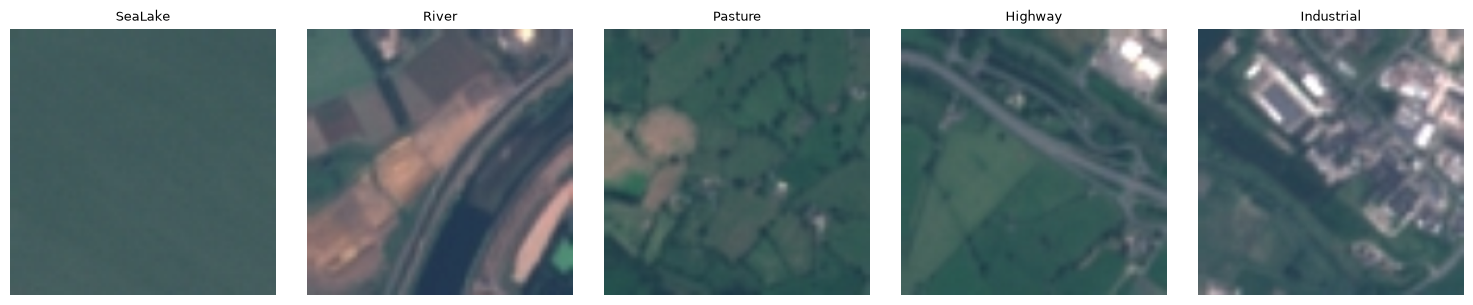

In [11]:
import random
import matplotlib.pyplot as plt
import torch

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

idx_to_class = {idx: name for name, idx in class_to_idx.items()}

plt.figure(figsize=(15, 3))

for i in range(5):
    idx = random.randint(0, len(val_dataset) - 1)

    image, label = val_dataset[idx]

    image = image * std + mean
    image = image.permute(1, 2, 0).numpy()

    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.title(idx_to_class[label], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Observation

The sample image is displayed correctly after reversing the normalization process. This confirms that:

- Images are loaded successfully.
- Data transformations are applied correctly.
- Labels are aligned with the corresponding images.

The data pipeline is now verified and ready for building PyTorch DataLoaders.

## Conclusion

The data pipeline has been verified successfully.

Completed tasks:

- Created a stratified train-validation split.
- Built a custom PyTorch dataset.
- Verified image loading and preprocessing.
- Confirmed that labels are mapped correctly.

The dataset is now ready for creating PyTorch DataLoaders and training the baseline CNN model.

# 6. Create PyTorch DataLoaders

PyTorch DataLoaders are responsible for loading data in mini-batches during training and validation.

Using DataLoaders improves training efficiency by batching samples, shuffling the training data, and enabling parallel data loading.

In [12]:
from torch.utils.data import DataLoader

from src.config import BATCH_SIZE

In [13]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

In [14]:
print(f"Training Batches   : {len(train_loader)}")
print(f"Validation Batches : {len(val_loader)}")
print(f"Batch Size         : {BATCH_SIZE}")

Training Batches   : 675
Validation Batches : 169
Batch Size         : 32


In [15]:
images, labels = next(iter(train_loader))

print("Images Shape :", images.shape)
print("Labels Shape :", labels.shape)

Images Shape : torch.Size([32, 3, 224, 224])
Labels Shape : torch.Size([32])


### Observation

The DataLoaders were created successfully.

- Training data is shuffled before every epoch.
- Validation data remains in a fixed order.
- Images are loaded in mini-batches, making the pipeline ready for model training.

The data pipeline is now fully complete.